# Lorenz-63 System


In [142]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

In [143]:
def lorenz_system(state, sigma=10.0, rho=28.0, beta=8/3):
    x, y, z = state
    
    dx_dt = sigma * (y - x)
    dy_dt = x * (rho - z) - y
    dz_dt = x * y - beta * z
    
    return np.array([dx_dt, dy_dt, dz_dt])

In [144]:
def rk4_step(state, dt):
    k1 = lorenz_system(state)
    k2 = lorenz_system(state + (dt / 2) * k1)
    k3 = lorenz_system(state + (dt / 2) * k2)
    k4 = lorenz_system(state + dt * k3)
    
    return state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

In [145]:
dt = 2.5e-2
total_steps = int(4e6)

In [146]:
current_state = np.array([1.0, 1.0, 1.0])
trajectory = []

In [147]:
for i in range(total_steps):
    trajectory.append(current_state)
    current_state = rk4_step(current_state, dt)

# Convert to a numpy array for easy handling
trajectory = np.array(trajectory)

print(f"Generated data shape: {trajectory.shape}")

Generated data shape: (4000000, 3)


In [148]:
trajectory[:5,:]

array([[1.        , 1.        , 1.        ],
       [1.07545053, 1.65930813, 0.96861164],
       [1.2876899 , 2.39988521, 0.96379682],
       [1.63448705, 3.30797486, 1.00201622],
       [2.13310847, 4.47105098, 1.11389662]])

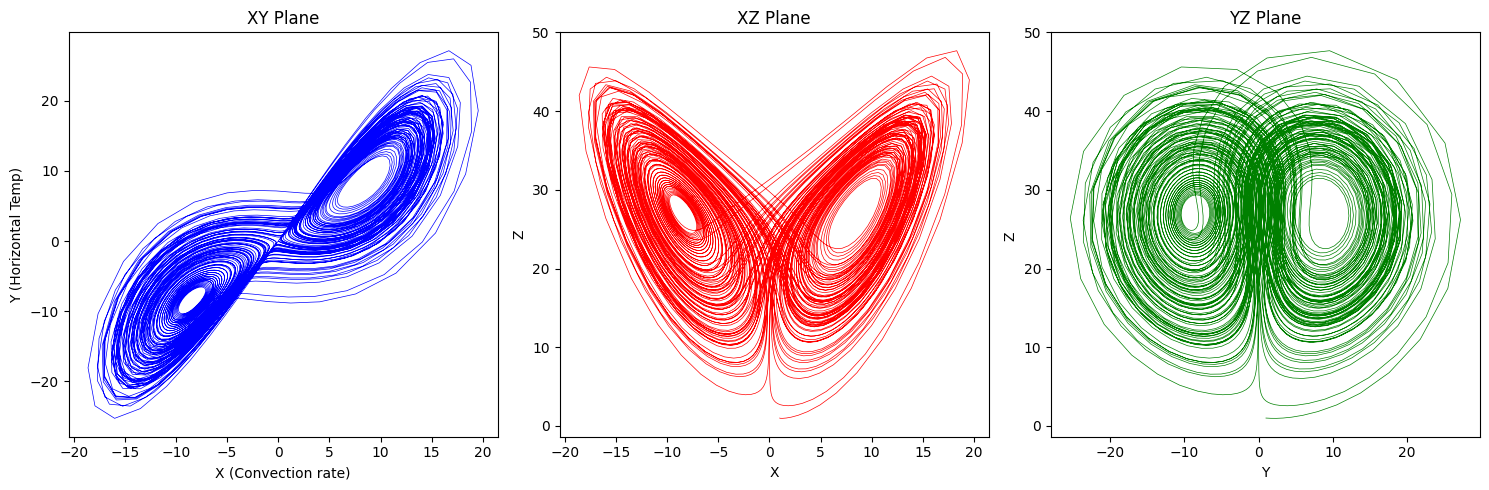

In [149]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.plot(trajectory[:5000, 0], trajectory[:5000, 1], color='blue', lw=0.5)
ax1.set_xlabel('X (Convection rate)')
ax1.set_ylabel('Y (Horizontal Temp)')
ax1.set_title('XY Plane')


ax2.plot(trajectory[:5000, 0], trajectory[:5000, 2], color='red', lw=0.5)
ax2.set_xlabel('X')
ax2.set_ylabel('Z')
ax2.set_title('XZ Plane')


ax3.plot(trajectory[:5000, 1], trajectory[:5000, 2], color='green', lw=0.5)
ax3.set_xlabel('Y')
ax3.set_ylabel('Z ')
ax3.set_title('YZ Plane')

plt.tight_layout()
plt.show()

In [150]:
def create_joint_windows(trajectory, n=2):
    total_steps = len(trajectory)
    num_possible_windows = total_steps - (n - 1)
    windows = []
    for i in range(num_possible_windows):
        window_segment = trajectory[i : i + n]
        flat_vector = window_segment.flatten()
        windows.append(flat_vector)

    return np.array(windows)

In [151]:
time_windows = create_joint_windows(trajectory)
print(f"Time window data shape: {time_windows.shape}")

Time window data shape: (3999999, 6)


In [152]:
print(time_windows[:5,:])

[[1.         1.         1.         1.07545053 1.65930813 0.96861164]
 [1.07545053 1.65930813 0.96861164 1.2876899  2.39988521 0.96379682]
 [1.2876899  2.39988521 0.96379682 1.63448705 3.30797486 1.00201622]
 [1.63448705 3.30797486 1.00201622 2.13310847 4.47105098 1.11389662]
 [2.13310847 4.47105098 1.11389662 2.81735656 5.98633224 1.35396999]]


In [153]:
train_dataset = time_windows[:int(1e6),:]

In [154]:
train_mean = np.mean(train_dataset, axis=0)
train_std = np.std(train_dataset, axis=0)

epsilon = 1e-8

normalized_train_dataset = (train_dataset - train_mean) / (train_std + epsilon)

In [155]:
print(f'Number of time windows (samples) in the Training Dataset = {len(train_dataset)}')

Number of time windows (samples) in the Training Dataset = 1000000


In [156]:
class customDataset(Dataset):
    def __init__(self,x):
        self.features = torch.tensor(x,dtype = torch.float32)
    
    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self,index):
        return self.features[index,:]

In [157]:
train_dataset = customDataset(normalized_train_dataset)
train_dataloader = DataLoader(normalized_train_dataset,batch_size = 500, shuffle=True)

In [158]:
class ContinuousNADE(nn.Module):
    def __init__(self,input_dim = 6, hidden_dim = 1000):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.W = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.01)
        self.c = nn.Parameter(torch.zeros(hidden_dim))

        self.V_mu = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_mu = nn.Parameter(torch.zeros(input_dim))

        self.V_log_sigma = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_log_sigma = nn.Parameter(torch.zeros(input_dim))

    def forward(self,x):
        batch_size = x.shape[0]

        mu_outputs = torch.zeros_like(x)
        log_sigma_outputs = torch.zeros_like(x)

        a_i = self.c.repeat(batch_size,1)

        for i in range(self.input_dim):
            h_i = torch.relu(a_i)
            mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
            log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]
            log_sigma_i = torch.clamp(log_sigma_i, min=-5, max=2)
            mu_outputs[:, i] = mu_i
            log_sigma_outputs[:, i] = log_sigma_i

            if i < self.input_dim - 1:
                v_i = x[:, i].unsqueeze(1)
                W_i = self.W[:, i].unsqueeze(0)
                a_i = a_i + v_i * W_i

        return mu_outputs, log_sigma_outputs

    def sample(self):
        generated_sequence = torch.zeros(self.input_dim)
        a_i = self.c.clone()

        with torch.no_grad():
            for i in range(self.input_dim):
                h_i = torch.relu(a_i)
                mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
                log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]

                sigma_i = torch.exp(log_sigma_i)
                sampled_value = mu_i + sigma_i * torch.randn(1, device=mu_i.device)
                generated_sequence[i] = sampled_value
                if i < self.input_dim - 1:
                    a_i = a_i + self.W[:, i] * sampled_value

        return generated_sequence

In [159]:
def gaussian_nll_loss(mu, log_sigma, target):

    variance = torch.exp(log_sigma) ** 2
    loss = 0.5 * ((target - mu) ** 2 / variance) + log_sigma + 0.5 * np.log(2 * np.pi)
    # Sum across the 6 dimensions, then get the mean for the batch
    return loss.sum(dim=1).mean()

In [160]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ContinuousNADE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001) 
train_loss_history = []
epochs = 50

# Simple Training Loop
for epoch in range(epochs):
    train_loss = 0.0
    model.train()
    
    for batch in train_dataloader:
        batch = batch.float().to(device)
        
        optimizer.zero_grad()
        mu_outputs, log_sigma_outputs = model(batch)
        loss = gaussian_nll_loss(mu_outputs, log_sigma_outputs, batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_loss = train_loss / len(train_dataloader)
    train_loss_history.append(avg_loss)
    if (epoch+1)%5 ==0:
        print(f'Epoch {epoch+1}/{epochs} | Avg Train Loss: {avg_loss:.4f}')

Epoch 5/50 | Avg Train Loss: -11.1022
Epoch 10/50 | Avg Train Loss: -11.4520
Epoch 15/50 | Avg Train Loss: -11.6158
Epoch 20/50 | Avg Train Loss: -11.8415
Epoch 25/50 | Avg Train Loss: -11.8934
Epoch 30/50 | Avg Train Loss: -12.0157
Epoch 35/50 | Avg Train Loss: -12.1023
Epoch 40/50 | Avg Train Loss: -11.9454
Epoch 45/50 | Avg Train Loss: -12.1219
Epoch 50/50 | Avg Train Loss: -12.1851


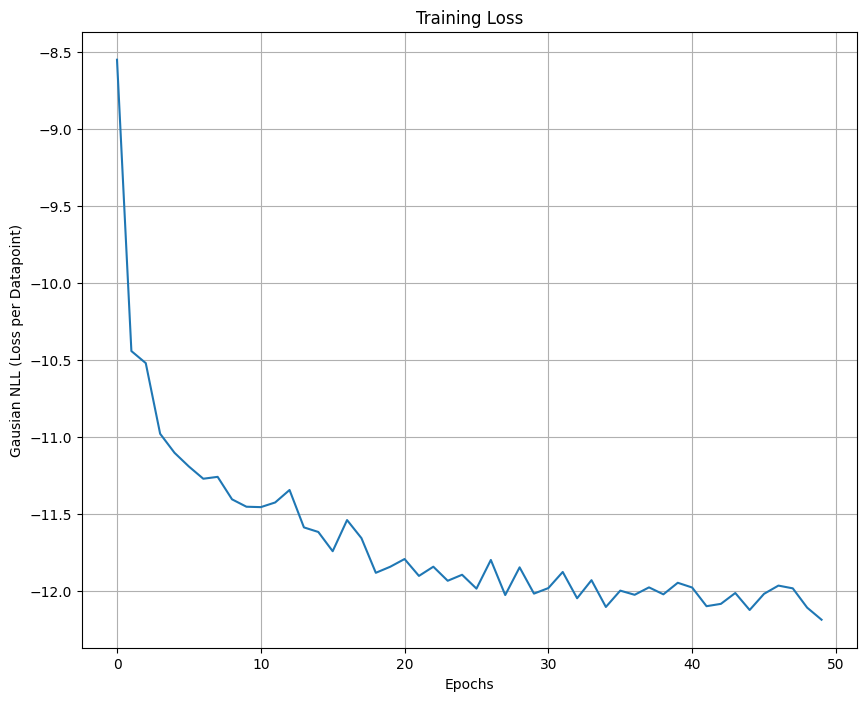

In [187]:
plt.figure(figsize=(10,8))
plt.plot(range(epochs),train_loss_history)
plt.xlabel('Epochs')
plt.ylabel('Gausian NLL (Loss per Datapoint)')
plt.title('Training Loss')
plt.grid(True)


In [ ]:
available_ground_truth = time_windows[int(1e6),:]
print(f'Avaible ground truth at last time step {available_ground_truth}')

Avaible ground truth at last time step [-5.24735532 -8.15655177 17.50390855 -6.0326469  -9.41369435 17.57328016]


In [163]:
generate_samples = int(1e6)
time_window_samples = []
with torch.no_grad():
    for i in range(generate_samples):
        time_window_samples.append(model.sample())

        current_count = i + 1
        if current_count % 100000 == 0:
            print(current_count, "/", generate_samples, "have been generated")

100000 / 1000000 have been generated
200000 / 1000000 have been generated
300000 / 1000000 have been generated
400000 / 1000000 have been generated
500000 / 1000000 have been generated
600000 / 1000000 have been generated
700000 / 1000000 have been generated
800000 / 1000000 have been generated
900000 / 1000000 have been generated
1000000 / 1000000 have been generated


In [164]:
candidates = torch.stack(time_window_samples).to(device)
mu_tensor = torch.tensor(train_mean, device=candidates.device)
std_tensor = torch.tensor(train_std, device=candidates.device)
unnormalized_candidates = (candidates * std_tensor) + mu_tensor
candidate_tails = unnormalized_candidates[:, :3]
candidate_heads = unnormalized_candidates[:, 3:]

In [182]:
forecast_horizon = int(1e5)
forecasted_trajectory = []
current_state = torch.tensor(available_ground_truth[3:], dtype=torch.float32).to(device)

In [183]:
for i in range(forecast_horizon):
    distances = torch.norm(candidate_tails - current_state, dim=1)
    best_index = torch.argmin(distances)
    winning_forecast = candidate_heads[best_index]
    forecasted_trajectory.append(winning_forecast.cpu().numpy())
    current_state = winning_forecast

In [184]:
forecasted_trajectory = np.array(forecasted_trajectory)
print(f"Forecasting complete! Shape: {forecasted_trajectory.shape}")

Forecasting complete! Shape: (100000, 3)


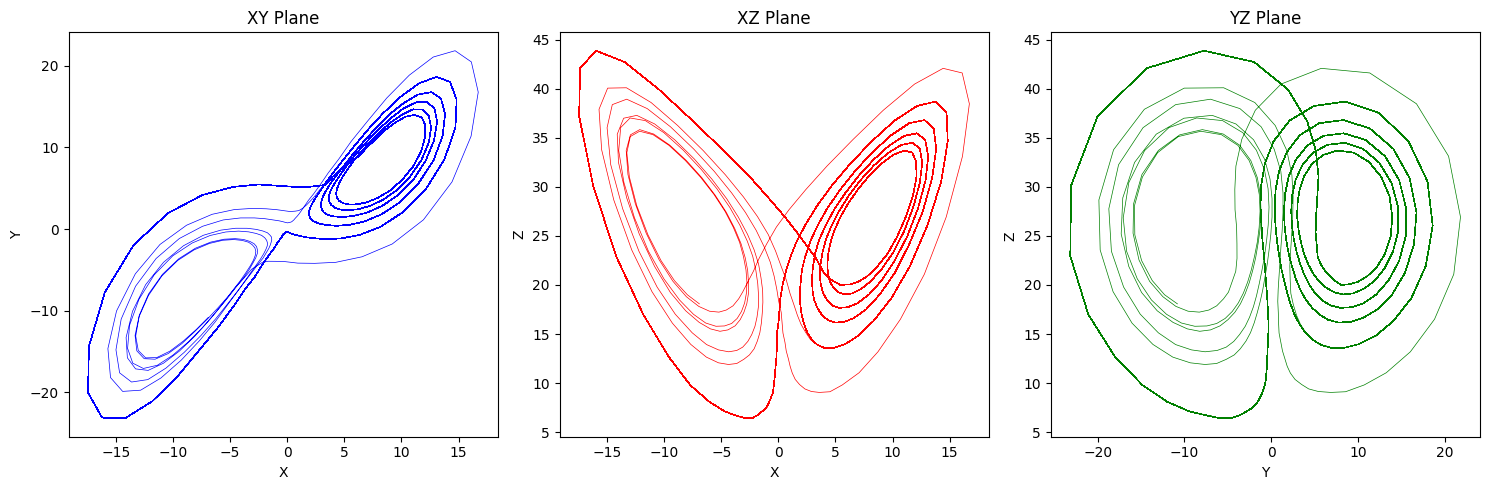

In [185]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.plot(forecasted_trajectory[:, 0], forecasted_trajectory[:, 1], color='blue', lw=0.5)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_title('XY Plane')


ax2.plot(forecasted_trajectory[:, 0], forecasted_trajectory[:, 2], color='red', lw=0.5)
ax2.set_xlabel('X')
ax2.set_ylabel('Z')
ax2.set_title('XZ Plane')


ax3.plot(forecasted_trajectory[:, 1], forecasted_trajectory[:, 2], color='green', lw=0.5)
ax3.set_xlabel('Y')
ax3.set_ylabel('Z ')
ax3.set_title('YZ Plane')

plt.tight_layout()
plt.show()

In [169]:
start_idx = 1000000 
end_idx = 4000000
num_samples = 500

#Creating 500 base points equally spaced (every 6000 steps)
base_points = np.linspace(start_idx, end_idx - 1000, num_samples).astype(int)
random_offsets = np.random.randint(0, 1000, size=num_samples)
test_start_indices = base_points + random_offsets
print(f"First 5 indices: {test_start_indices[:5]}")

First 5 indices: [1000583 1006943 1012359 1018584 1024759]


In [170]:
all_preds = []
all_ground_truth = []

In [171]:
mu_tensor = torch.tensor(train_mean, device=device)
std_tensor = torch.tensor(train_std, device=device)
for idx in test_start_indices:
    current_state = torch.tensor(time_windows[idx, :3], device=device, dtype=torch.float32)
    truth = time_windows[idx : idx+400, 3:]
    all_ground_truth.append(truth)
    forecast = []

    for step in range(400):
        with torch.no_grad():
            distances = torch.norm(candidate_tails - current_state, dim=1)
            best_index = torch.argmin(distances)
            winning_forecast = candidate_heads[best_index]
        forecast.append(winning_forecast.cpu().numpy())
        current_state = winning_forecast
    all_preds.append(np.array(forecast))

In [172]:
all_preds = np.array(all_preds)
all_ground_truth = np.array(all_ground_truth)
mae_per_step = np.mean(np.abs(all_preds - all_ground_truth), axis=0)   #400x3

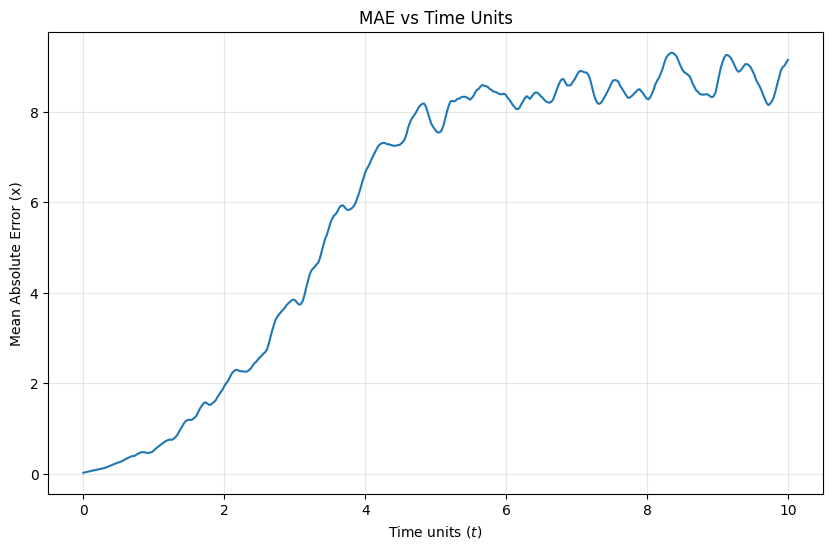

In [173]:
time_axis = np.linspace(0, 10, 400) 
plt.figure(figsize=(10, 6))

plt.plot(time_axis, mae_per_step[:, 0])

plt.xlabel('Time units ($t$)')
plt.ylabel('Mean Absolute Error (x)')
plt.title('MAE vs Time Units')
plt.grid(True, alpha=0.3)
plt.show()

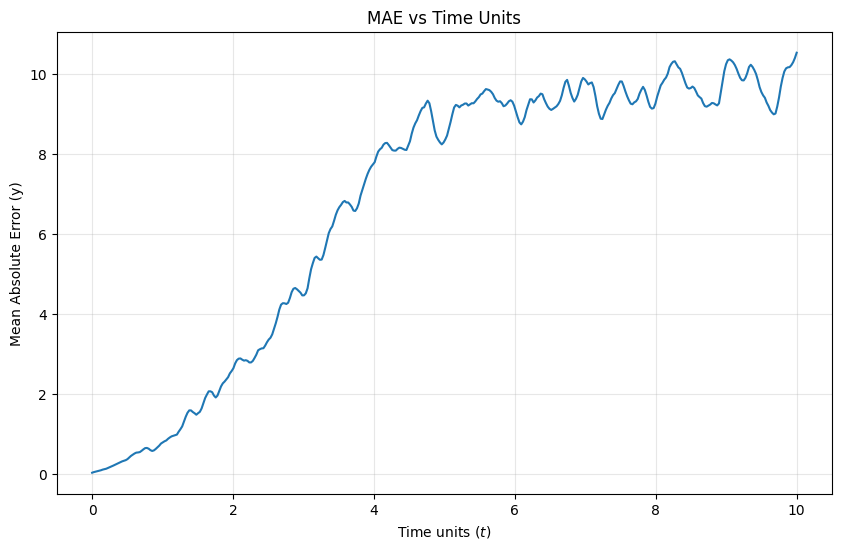

In [177]:
time_axis = np.linspace(0, 10, 400) 
plt.figure(figsize=(10, 6))

plt.plot(time_axis, mae_per_step[:, 1])

plt.xlabel('Time units ($t$)')
plt.ylabel('Mean Absolute Error (y)')
plt.title('MAE vs Time Units')
plt.grid(True, alpha=0.3)
plt.show()

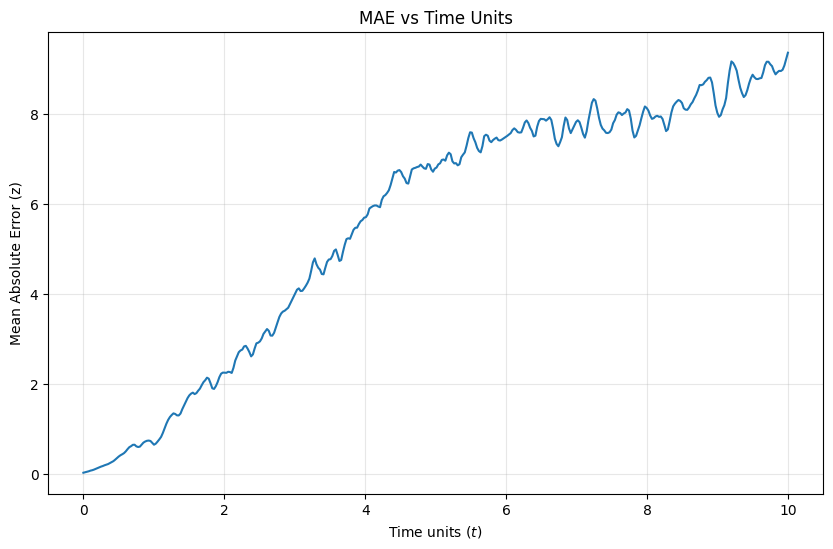

In [179]:
time_axis = np.linspace(0, 10, 400) 
plt.figure(figsize=(10, 6))

plt.plot(time_axis, mae_per_step[:, 2])

plt.xlabel('Time units ($t$)')
plt.ylabel('Mean Absolute Error (z)')
plt.title('MAE vs Time Units')
plt.grid(True, alpha=0.3)
plt.show()

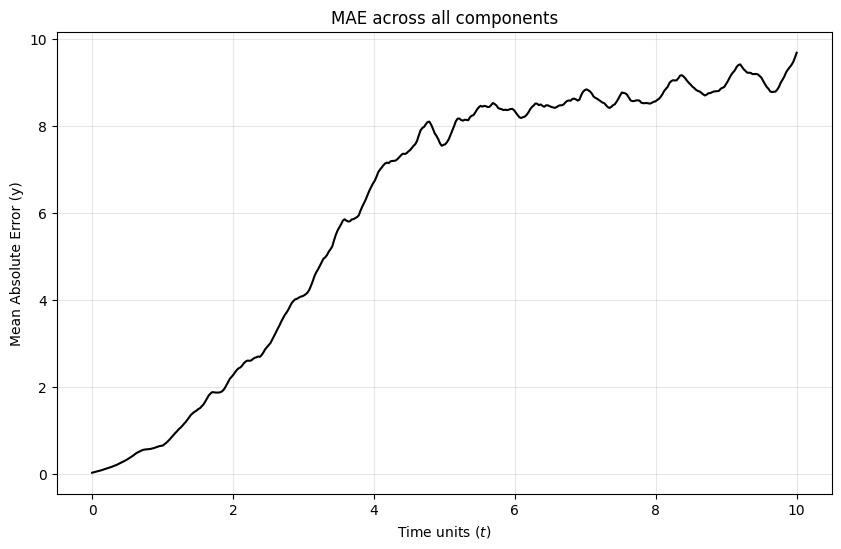

In [175]:
plt.figure(figsize=(10, 6))

mean_mae = np.mean(mae_per_step, axis=1)
plt.plot(time_axis, mean_mae, color='black')

plt.xlabel('Time units ($t$)')
plt.ylabel('Mean Absolute Error')
plt.title('MAE across all components')
plt.grid(True, alpha=0.3)
plt.show()